# Granger Causality: Betti-0 vs Market Stress Indicators

Supplementary experiment for reviewer response.

**Question**: Does topological change (Betti-0) *lead* market stress, *lag* it, or is the relationship bidirectional?

**Design**:
1. ADF stationarity test → difference I(1) variables
2. Granger F-test at lags 1, 3, 5, 7, 10, 14, 21 days
3. Both directions: TDA→Market and Market→TDA
4. All 4 Betti-0 variants × 5 market indicators = 20 pairs

In [1]:
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
from matplotlib.patches import Patch
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

DATA_PATH = Path('/Users/jane/Documents/202511吾-Systems/3.Data/'
                 'TDA_SP500_VIX_BTC_BVOL_CVI_merged0329_labeled_with_network.csv')
DATA_OUT  = Path('/Users/jane/Documents/202511吾-Systems/12.Data0329')

df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
for c in ['VIX','BVOL','SP500']: df[c] = df[c].ffill()

TDA_COLS    = ['log_dtw_betti0','log_wass_betti0','vol_dtw_betti0','vol_wass_betti0']
MARKET_COLS = ['VIX','BVOL','SP500','fng_value','vol_btc_rogers']
LAGS        = [1, 3, 5, 7, 10, 14, 21]
I1_COLS     = {'BVOL','SP500','log_dtw_betti0'}   # ADF p > 0.05 at levels

TDA_LABELS = {
    'log_dtw_betti0': 'log-DTW\nBetti-0', 'log_wass_betti0': 'log-Wass\nBetti-0',
    'vol_dtw_betti0': 'vol-DTW\nBetti-0', 'vol_wass_betti0': 'vol-Wass\nBetti-0',
}
MKT_LABELS = {
    'VIX':'VIX','BVOL':'BVOL','SP500':'S&P 500',
    'fng_value':'Fear &\nGreed','vol_btc_rogers':'BTC Vol\n(Rogers)',
}


In [2]:
# ── Step 1: Stationarity ─────────────────────────────────────────────────────
rows = []
for col in TDA_COLS + MARKET_COLS:
    s = df[col].dropna()
    p  = adfuller(s, autolag='AIC')[1]
    pd_ = adfuller(s.diff().dropna(), autolag='AIC')[1]
    rows.append({'variable':col,'ADF_p_level':round(p,4),'stationary_level':p<0.05,
                 'ADF_p_diff':round(pd_,4),'stationary_diff':pd_<0.05})
stat_df = pd.DataFrame(rows)
stat_df.to_csv(DATA_OUT/'tbl_granger_stationarity.csv', index=False)
display(stat_df)


,variable,ADF_p_level,stationary_level,ADF_p_diff,stationary_diff
0,log_dtw_betti0,0.0514,False,0.0,True
1,log_wass_betti0,0.0326,True,0.0,True
2,vol_dtw_betti0,0.0062,True,0.0,True
3,vol_wass_betti0,0.0045,True,0.0,True
4,VIX,0.0000,True,0.0,True
5,BVOL,0.1918,False,0.0,True
6,SP500,0.9577,False,0.0,True
7,fng_value,0.0019,True,0.0,True
8,vol_btc_rogers,0.0000,True,0.0,True


In [3]:
# ── Step 2: Granger tests ────────────────────────────────────────────────────
def prepare(col):
    s = df[col].dropna().reset_index(drop=True)
    return s.diff().dropna().reset_index(drop=True) if col in I1_COLS else s

def run_granger(x, y, maxlag):
    data = pd.concat([y, x], axis=1).dropna()
    if len(data) < maxlag*5: return np.nan
    try:
        res = grangercausalitytests(data, maxlag=maxlag, verbose=False)
        return min(res[l][0]['ssr_ftest'][1] for l in range(1, maxlag+1))
    except: return np.nan

rows = []
for tda in TDA_COLS:
    xs = prepare(tda)
    for mkt in MARKET_COLS:
        ys = prepare(mkt)
        n = min(len(xs), len(ys))
        for lag in LAGS:
            rows.append({'tda':tda,'market':mkt,'lag':lag,
                         'p_TDA_causes_Market': run_granger(xs.iloc[:n], ys.iloc[:n], lag),
                         'p_Market_causes_TDA': run_granger(ys.iloc[:n], xs.iloc[:n], lag)})

gc_df = pd.DataFrame(rows)
gc_df['TDA_causes_Market'] = gc_df['p_TDA_causes_Market'] < 0.05
gc_df['Market_causes_TDA'] = gc_df['p_Market_causes_TDA'] < 0.05
gc_df.to_csv(DATA_OUT/'tbl_granger_causality_full.csv', index=False)
print(f'Tests run: {len(gc_df)}')
display(gc_df.head(14))


Tests run: 140


,tda,market,lag,p_TDA_causes_Market,p_Market_causes_TDA,TDA_causes_Market,Market_causes_TDA
0,log_dtw_betti0,VIX,1,5.526890e-01,0.464872,False,False
1,log_dtw_betti0,VIX,3,5.526890e-01,0.464872,False,False
2,log_dtw_betti0,VIX,5,5.526890e-01,0.464872,False,False
3,log_dtw_betti0,VIX,7,5.526890e-01,0.464872,False,False
4,log_dtw_betti0,VIX,10,5.526890e-01,0.464872,False,False
5,log_dtw_betti0,VIX,14,5.526890e-01,0.464872,False,False
6,log_dtw_betti0,VIX,21,1.675643e-02,0.464872,True,False
7,log_dtw_betti0,BVOL,1,5.603482e-03,0.873943,True,False
8,log_dtw_betti0,BVOL,3,5.603482e-03,0.312752,True,False
9,log_dtw_betti0,BVOL,5,5.603482e-03,0.204765,True,False


In [4]:
# ── Step 3: Summary table ────────────────────────────────────────────────────
srows = []
for tda in TDA_COLS:
    for mkt in MARKET_COLS:
        sub = gc_df[(gc_df['tda']==tda)&(gc_df['market']==mkt)]
        s_t2m = sub[sub['TDA_causes_Market']]['lag'].tolist()
        s_m2t = sub[sub['Market_causes_TDA']]['lag'].tolist()
        rel = ('Bidirectional'    if s_t2m and s_m2t else
               'TDA leads Market' if s_t2m else
               'Market leads TDA' if s_m2t else 'No causality')
        srows.append({'TDA indicator':tda,'Market indicator':mkt,
                      'TDA→Market sig. lags':str(s_t2m),
                      'Market→TDA sig. lags':str(s_m2t),
                      'Relationship':rel,
                      'min_p_TDA→Market':round(sub['p_TDA_causes_Market'].min(),4),
                      'min_p_Market→TDA':round(sub['p_Market_causes_TDA'].min(),4)})
summary_df = pd.DataFrame(srows)
summary_df.to_csv(DATA_OUT/'tbl_granger_causality_summary.csv', index=False)
display(summary_df)


,TDA indicator,Market indicator,TDA→Market sig. lags,Market→TDA sig. lags,Relationship,min_p_TDA→Market,min_p_Market→TDA
0,log_dtw_betti0,VIX,[21],[],TDA leads Market,0.0168,0.4649
1,log_dtw_betti0,BVOL,"[1, 3, 5, 7, 10, 14, 21]","[10, 14, 21]",Bidirectional,0.0000,0.0000
2,log_dtw_betti0,SP500,[],[],No causality,0.6478,0.8071
3,log_dtw_betti0,fng_value,[],"[1, 3, 5, 7, 10, 14, 21]",Market leads TDA,0.0982,0.0024
4,log_dtw_betti0,vol_btc_rogers,"[14, 21]","[1, 3, 5, 7, 10, 14, 21]",Bidirectional,0.0000,0.0000
5,log_wass_betti0,VIX,[],[],No causality,0.1331,0.1234
6,log_wass_betti0,BVOL,"[1, 3, 5, 7, 10, 14, 21]","[1, 3, 5, 7, 10, 14, 21]",Bidirectional,0.0000,0.0018
7,log_wass_betti0,SP500,[],[],No causality,0.3532,0.4069
8,log_wass_betti0,fng_value,"[3, 5, 7, 10, 14, 21]","[1, 3, 5, 7, 10, 14, 21]",Bidirectional,0.0053,0.0036
9,log_wass_betti0,vol_btc_rogers,"[1, 3, 5, 7, 10, 14, 21]","[10, 14, 21]",Bidirectional,0.0000,0.0000


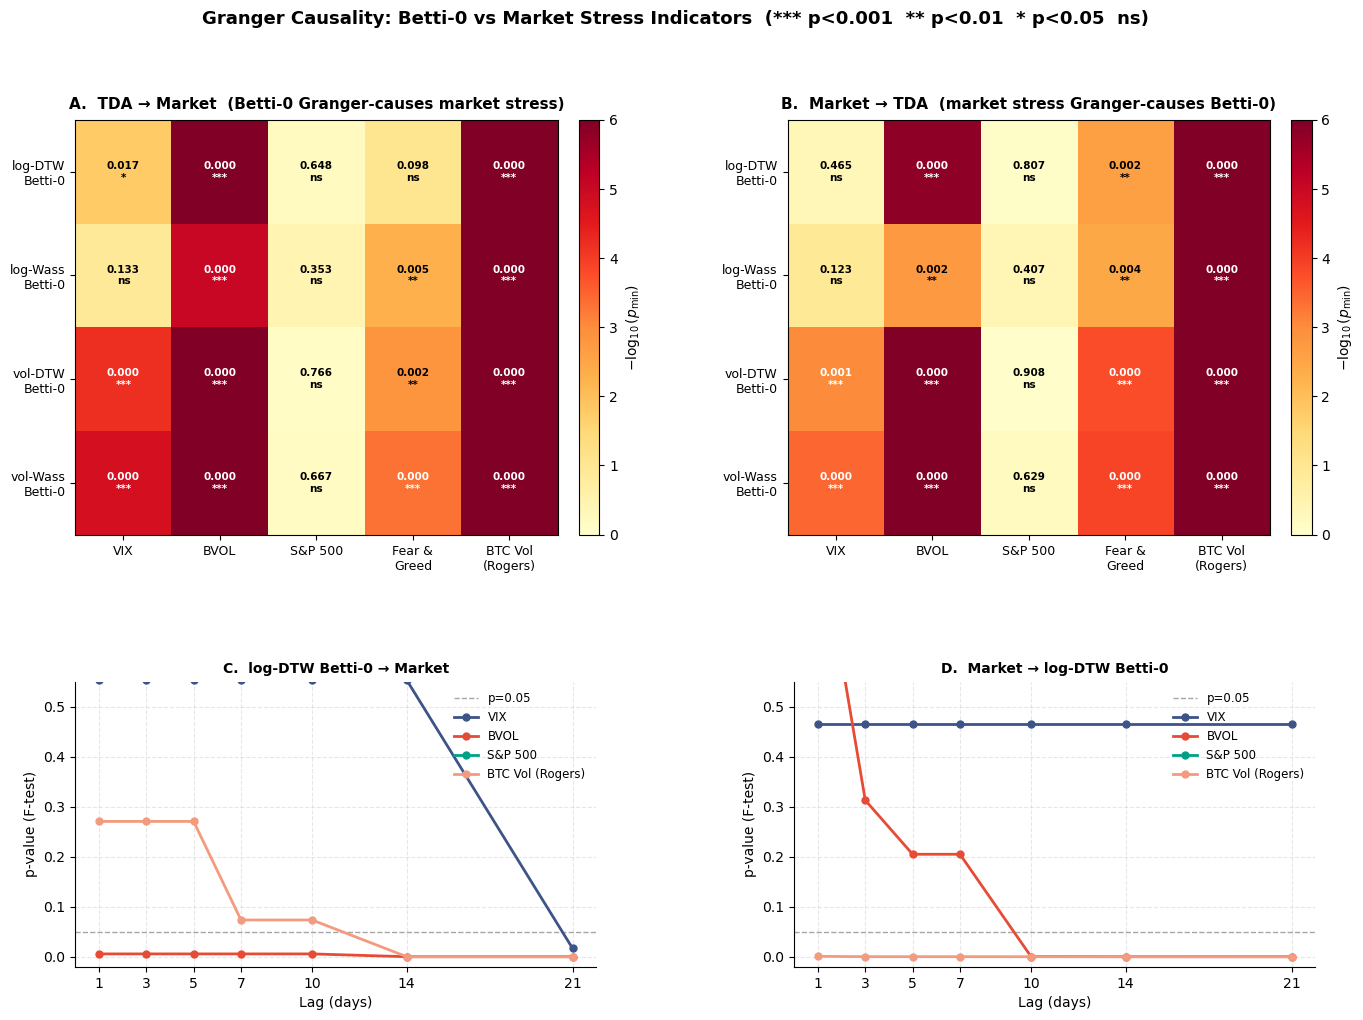

Figure 1 saved.


In [5]:
# ── Figure 1: p-value heatmaps + lag curves ──────────────────────────────────
fig = plt.figure(figsize=(16, 11))
gs_outer = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[3.2, 2.2], hspace=0.42)
gs_a = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0], wspace=0.35)

for pidx, (col_key, title) in enumerate([
    ('p_TDA_causes_Market', 'A.  TDA → Market  (Betti-0 Granger-causes market stress)'),
    ('p_Market_causes_TDA', 'B.  Market → TDA  (market stress Granger-causes Betti-0)'),
]):
    ax = fig.add_subplot(gs_a[pidx])
    mat = np.array([[gc_df[(gc_df['tda']==t)&(gc_df['market']==m)][col_key].min()
                     for m in MARKET_COLS] for t in TDA_COLS])
    nlp = -np.log10(np.clip(mat, 1e-10, 1.0))
    im  = ax.imshow(nlp, cmap='YlOrRd', vmin=0, vmax=6, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r'$-\log_{10}(p_{\min})$')
    ax.set_xticks(range(len(MARKET_COLS)))
    ax.set_xticklabels([MKT_LABELS[m] for m in MARKET_COLS], fontsize=9)
    ax.set_yticks(range(len(TDA_COLS)))
    ax.set_yticklabels([TDA_LABELS[t] for t in TDA_COLS], fontsize=9)
    for i in range(len(TDA_COLS)):
        for j in range(len(MARKET_COLS)):
            p = mat[i,j]
            sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
            ax.text(j, i, f'{p:.3f}\n{sig}', ha='center', va='center',
                    fontsize=7.5, color='white' if nlp[i,j]>3 else 'black', fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

MKT_COLORS = {'VIX':'#3C5488','BVOL':'#E64B35','SP500':'#00A087','vol_btc_rogers':'#F39B7F'}
MKT_PLOT   = ['VIX','BVOL','SP500','vol_btc_rogers']
gs_c = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[1], wspace=0.38)
for pidx, (reverse, label) in enumerate([(False,'C.  log-DTW Betti-0 → Market'),
                                           (True, 'D.  Market → log-DTW Betti-0')]):
    ax = fig.add_subplot(gs_c[pidx])
    ax.axhline(0.05, color='grey', lw=1.0, ls='--', alpha=0.7, label='p=0.05')
    col_key = 'p_Market_causes_TDA' if reverse else 'p_TDA_causes_Market'
    for mkt in MKT_PLOT:
        ps = [gc_df[(gc_df['tda']=='log_dtw_betti0')&(gc_df['market']==mkt)&
                    (gc_df['lag']==lag)][col_key].values[0] for lag in LAGS]
        ax.plot(LAGS, ps, color=MKT_COLORS[mkt], lw=2.0, marker='o', markersize=5,
                label=MKT_LABELS[mkt].replace('\n',' '))
    ax.set_xlabel('Lag (days)', fontsize=10); ax.set_ylabel('p-value (F-test)', fontsize=10)
    ax.set_ylim(-0.02, 0.55); ax.set_xticks(LAGS)
    ax.xaxis.grid(True,ls='--',alpha=0.3); ax.yaxis.grid(True,ls='--',alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=8.5, loc='upper right')
    ax.set_title(label, fontsize=10, fontweight='bold')

fig.suptitle('Granger Causality: Betti-0 vs Market Stress Indicators  '
             '(*** p<0.001  ** p<0.01  * p<0.05  ns)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(DATA_OUT/'fig_granger_causality.png', dpi=300, bbox_inches='tight')
fig.savefig(DATA_OUT/'fig_granger_causality.pdf', bbox_inches='tight')
plt.show(); print('Figure 1 saved.')


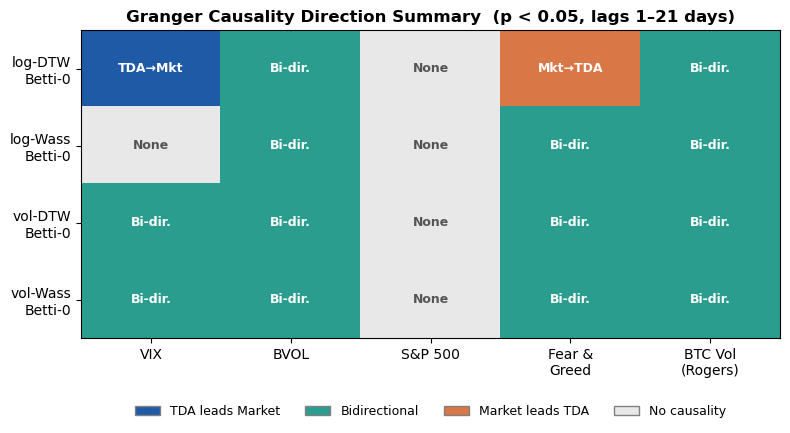

Figure 2 saved.


In [6]:
# ── Figure 2: Relationship direction summary ─────────────────────────────────
REL_MAP  = {'TDA leads Market':0,'Bidirectional':1,'Market leads TDA':2,'No causality':3}
REL_CMAP = ['#1f5aa6','#2a9d8f','#d97746','#e8e8e8']
REL_NAMES = list(REL_MAP.keys())

rel_mat = np.array([[REL_MAP[summary_df[(summary_df['TDA indicator']==t)&
                    (summary_df['Market indicator']==m)]['Relationship'].values[0]]
                     for m in MARKET_COLS] for t in TDA_COLS])

fig2, ax = plt.subplots(figsize=(8, 4.5))
ax.imshow(rel_mat, cmap=matplotlib.colors.ListedColormap(REL_CMAP),
          vmin=-0.5, vmax=3.5, aspect='auto')
ax.set_xticks(range(len(MARKET_COLS)))
ax.set_xticklabels([MKT_LABELS[m] for m in MARKET_COLS], fontsize=10)
ax.set_yticks(range(len(TDA_COLS)))
ax.set_yticklabels([TDA_LABELS[t] for t in TDA_COLS], fontsize=10)
short = {'TDA leads Market':'TDA→Mkt','Bidirectional':'Bi-dir.',
         'Market leads TDA':'Mkt→TDA','No causality':'None'}
for i in range(len(TDA_COLS)):
    for j in range(len(MARKET_COLS)):
        name = REL_NAMES[rel_mat[i,j]]
        ax.text(j, i, short[name], ha='center', va='center', fontsize=9,
                color='white' if rel_mat[i,j]<3 else '#555', fontweight='bold')
ax.legend(handles=[Patch(facecolor=c,edgecolor='grey',label=n)
                   for c,n in zip(REL_CMAP,REL_NAMES)],
          loc='upper center', bbox_to_anchor=(0.5,-0.18), ncol=4,
          fontsize=9, frameon=False)
ax.set_title('Granger Causality Direction Summary  (p < 0.05, lags 1–21 days)',
             fontsize=12, fontweight='bold')
fig2.tight_layout()
fig2.savefig(DATA_OUT/'fig_granger_direction_summary.png', dpi=300, bbox_inches='tight')
fig2.savefig(DATA_OUT/'fig_granger_direction_summary.pdf', bbox_inches='tight')
plt.show(); print('Figure 2 saved.')
